In [59]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob

import h5py
import flammkuchen as fl
import seaborn as sns
from matplotlib.cm import ScalarMappable
import scipy
from scipy import stats

In [61]:
from fig_2_helper import labels_cat, color, color_bouts, cmp_bouts, color_ipsi_cont

In [62]:
def reshape_feature_array(feature_vector_array):
    """
    Reshape the feature vector array into a specified shape and extract sub-arrays.

    Parameters:
    - feature_vector_array: numpy.ndarray, the array to be reshaped.

    Returns:
    - reshaped_array: numpy.ndarray, the reshaped array.
    - peaks_a_array, peaks_i_array, valleys_a_array, valleys_i_array: separate sub-arrays.
    """
    max_n = int(feature_vector_array.shape[1] / 4)

    # Reshape the array
    reshaped_array = feature_vector_array.reshape(feature_vector_array.shape[0], 4, max_n)

    # Extract sub-arrays
    peaks_a_array = reshaped_array[:, 0, :]
    peaks_i_array = reshaped_array[:, 1, :]
    valleys_a_array = reshaped_array[:, 2, :]
    valleys_i_array = reshaped_array[:, 3, :]

    print(f"Reshaped array shape: {reshaped_array.shape}")

    return reshaped_array, peaks_a_array, peaks_i_array, valleys_a_array, valleys_i_array
    
def resort_ipsi_contra_traces(left_fin, right_fin, ipsi_fin_values):
    """
    ipsi_fin = 0, left fin is ipsi, 
    ipsi_fin = 1, right fin is ipsi_fin,
    """
    ipsi_fin = np.zeros_like(left_fin)
    contra_fin = np.zeros_like(left_fin)

    for i, dir_value in enumerate(ipsi_fin_values):
        if dir_value == 0:  # Left 
            ipsi_fin[i] = left_fin[i]
            contra_fin[i] = right_fin[i]
        elif dir_value == 1:  # Right
            ipsi_fin[i] = right_fin[i]
            contra_fin[i] = left_fin[i]
    return ipsi_fin, contra_fin

def sort_ipsi_contra_arrays(array1, array2, ipsi_indicator):
    # Determine ipsilateral and contralateral
    """
    ipsi_fin = 0, left fin is ipsi, 
    ipsi_fin = 1, right fin is ipsi_fin,
    """
    ipsi_fin = np.full(array1.shape[0], np.nan)
    contra_fin = np.full(array2.shape[0], np.nan)

    for i, dir_value in enumerate(ipsi_indicator):
        if dir_value == 0:  # Left 
            ipsi_fin[i] = array1[i]
            contra_fin[i] = array2[i]
        elif dir_value == 1:  # Right
            ipsi_fin[i] = array2[i]
            contra_fin[i] = array1[i]
    return ipsi_fin, contra_fin

def get_ipsi_contra_col(df, col1, col2, ipsi_indicator_col):
    """
    Function to separate ipsilateral and contralateral fin durations.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    col1 (str): The name of the first duration column (e.g., 'l_fin_duration').
    col2 (str): The name of the second duration column (e.g., 'r_fin_duration').
    ipsi_indicator_col (str): The name of the column indicating which fin is ipsi (0 for col1, 1 for col2).

    Returns:
    np.ndarray: Array of ipsilateral fin durations.
    np.ndarray: Array of contralateral fin durations.
    """
    # Determine ipsilateral and contralateral durations
    ipsi_fin_duration = np.where(df[ipsi_indicator_col] == 0, df[col1], df[col2])
    contra_fin_duration = np.where(df[ipsi_indicator_col] == 0, df[col2], df[col1])
    
    return ipsi_fin_duration, contra_fin_duration
    

In [63]:
from scipy.stats import mannwhitneyu

# Define significance level
alpha = 0.05

# Function to annotate significance
def add_stat_annotation(ax, p_value, alpha, start, end, y, height, text):
    if p_value < alpha:
        ax.plot([start, end], [y, y], color='black')  # line between boxes
        ax.text((start + end) / 2, y + height, text, ha='center', va='bottom')

In [64]:
master_path = Path(r'\\portulab.synology.me\data\Kata\Processed_Data\tensor_data')
path_tensors = Path(master_path/ 'tensors'/ 'tensor_ipsi_contra.h5')
path_features = Path(master_path/ 'features_ipsi_contra.csv')
master_path, path_features

(WindowsPath('//portulab.synology.me/data/Kata/Processed_Data/tensor_data'),
 WindowsPath('//portulab.synology.me/data/Kata/Processed_Data/tensor_data/features_ipsi_contra.csv'))

In [65]:
save_figure_path = Path(r'\\portulab.synology.me\data\Kata\Figures_Paper\Figure_2\fig_2')

In [66]:
### tail, fin 1, fin 2, left eye, right eye

traces =  fl.load(path_tensors)
traces.shape

(11063, 3, 50)

In [67]:
tail = traces[:, 0, :]
fin_1 = traces[:, 1, :]
fin_2 = traces[:, 2, :]

### read in features

In [68]:
features = pd.read_csv(path_features)
features.head()

,Unnamed: 0.1,Unnamed: 0,exp,fish_id,bout_angle,cluster,frame_start,frame_end,bout_id_orig,mb_proba,...,ipsi_peak_vigor,contra_peak_vigor,ipsi_freqs,contra_freqs,ipsi_osc,contra_osc,ipsi_duration,contra_duration,ipsi_max_freqs,contra_max_freqs
0,0,0,13052024_visstim_2D_round,240513_f0,3.000171,0,18375,18410,78,0.806645,...,0.244681,0.164076,0.109756,0.105263,4,3,28.0,27.0,0.166667,0.166667
1,1,1,13052024_visstim_2D_round,240513_f0,1.649302,0,19461,19484,80,1.000000,...,0.163745,0.128555,0.119048,0.117647,2,2,19.0,15.0,0.250000,0.166667
2,2,2,13052024_visstim_2D_round,240513_f0,-0.861132,0,19661,19689,81,1.000000,...,0.219439,0.184779,0.104167,0.115385,3,2,27.0,16.0,0.125000,0.166667
3,3,3,13052024_visstim_2D_round,240513_f0,0.870591,0,20257,20292,84,1.000000,...,0.209418,0.198009,0.117647,0.117647,4,2,35.0,16.0,0.125000,0.166667
4,4,4,13052024_visstim_2D_round,240513_f0,2.231631,0,20824,20859,86,1.000000,...,0.220615,0.185247,0.103448,0.116667,3,3,22.0,23.0,0.125000,0.125000


In [69]:
clusters = features.cluster

In [70]:
tail_osc = features.tail_osc
ipsi_osc = features.ipsi_osc
contra_osc = features.contra_osc

In [71]:
datas = [tail_osc, ipsi_osc, contra_osc]
colors_ipsi_con = [color_ipsi_cont[-1], color_ipsi_cont[0], color_ipsi_cont[1]]

# Histograms

In [72]:
lw=0.5
cm = 1/2.54  # centimeters in inches
f_size = 6
dpi=600
alph= 0.5
width = 0.35  # Width of the bars


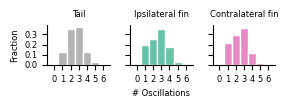

In [74]:

# Plotting
fig, axes = plt.subplots(1, 3,figsize=(7.5*cm, 3*cm), facecolor='None',sharex=True, sharey=True)
axes = axes.ravel()

for ind, data in enumerate(datas):
    # Assuming oscillations is your existing 2D numpy array
    total = np.size(data, 0)
    #Calculate counts for each unique value in each column
    counts = []
    unique_values, counts_i = np.unique(data, return_counts=True)
    counts.append((unique_values, counts_i))
    # Calculate normalized counts
    normalized_counts = counts_i / total
    # normalized_counts = (counts_i / total)*100
    
    # Make histogram
    axes[ind].bar(unique_values, normalized_counts, width=1, edgecolor='white', color=colors_ipsi_con[ind])
    axes[ind].set_xticks(unique_values)  # Ensure x-axis ticks are the unique values in the column

axes[0].set_ylabel('Fraction', fontsize=f_size)
axes[0].set_title('Tail', fontsize=f_size)
axes[1].set_title('Ipsilateral fin', fontsize=f_size)
axes[2].set_title('Contralateral fin', fontsize=f_size)
axes[1].set_xlabel('# Oscillations', fontsize=f_size)

for ax in axes:
    ax.set_xticks(np.arange(0,7,1))
    ax.set_xticklabels(np.arange(0,7,1), fontsize=f_size)
    ax.set_yticks(np.arange(0,0.4,0.1))
    ax.set_yticklabels(np.round(np.arange(0,0.4,0.1),2), fontsize=f_size)

sns.despine(top=True, right=True, left=False, bottom=False)
plt.tight_layout()

plt.savefig(save_figure_path/ 'oscillations_ipsi_contra.pdf', dpi=dpi)
plt.savefig(save_figure_path/ 'oscillations_ipsi_contra.png', dpi=dpi)

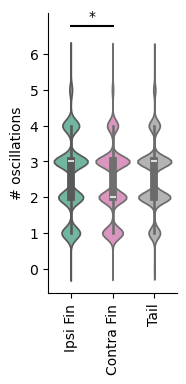

In [58]:
# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(ipsi_osc, contra_osc, alternative='two-sided')

# Plot
plt.figure(figsize=(5*cm, 10*cm), facecolor='None')
# Create horizontal boxplots
sns.violinplot(y=ipsi_osc, x=['ipsilateral fin'] * len(ipsi_osc), color=color_ipsi_cont[0])
sns.violinplot(y=contra_osc, x=['contralateral fin'] * len(contra_osc), color=color_ipsi_cont[1])
sns.violinplot(y=tail_osc, x=['tail'] * len(tail_osc), color=color_ipsi_cont[-1])

plt.ylabel('# oscillations', fontsize=f_size)
plt.xticks(np.arange(0,3,1),labels=['Ipsi Fin', 'Contra Fin', 'Tail'], fontsize=f_size, rotation=90)
plt.yticks(np.arange(0,7,1),labels=np.arange(0,7,1), fontsize=f_size)

# Add statistical annotation
ax = plt.gca()  # Get current axes
y_max = max(max(ipsi_osc), max(contra_osc))
add_stat_annotation(
    ax=ax,
    p_value=p_value,
    alpha=alpha,
    start=0,  # Start of the line for the first boxplot
    end=1,    # End of the line for the second boxplot
    y=y_max+0.5 + (0.05 * y_max),  # Y position above the maximum y value
    height=0.01 * y_max,  # Space for the text annotation
    text='*' if p_value < alpha else 'ns'  # '*' for significant, 'ns' for not significant
)

sns.despine(top=True, right=True, left=False, bottom=False)
plt.tight_layout()

# Save the figure if needed
plt.savefig(save_figure_path / 'oscillations_ipsi_contra_violin.pdf', dpi=dpi)
plt.savefig(save_figure_path / 'oscillations_ipsi_contra_violin.png', dpi=dpi)


### Stats

In [75]:
import numpy as np
import scipy.stats as stats

# Assuming your datasets are numpy arrays
# if they are list, you can convert them using: np.array(your_list)
tail_osc = np.array(tail_osc)
ipsi_osc = np.array(ipsi_osc)
contra_osc = np.array(contra_osc)

datasets = [tail_osc, ipsi_osc, contra_osc]

for index, data in enumerate(datasets):
    mean = np.mean(data)
    sigma = np.std(data)
    confidence_interval = stats.norm.interval(0.9, loc=mean, scale=sigma)

    # Round the confidence interval to the nearest whole number
    rounded_ci = (round(confidence_interval[0]), round(confidence_interval[1])) 

    print(f"For dataset {index+1}, 90% of the time the numbers fall into this range: {rounded_ci}")


For dataset 1, 90% of the time the numbers fall into this range: (1, 4)
For dataset 2, 90% of the time the numbers fall into this range: (1, 4)
For dataset 3, 90% of the time the numbers fall into this range: (1, 4)


In [76]:
import numpy as np
from scipy import stats

# Assuming your datasets are numpy arrays
# if they are lists, you can convert them using: np.array(your_list)
ipsi_osc = np.array(ipsi_osc)
contra_osc = np.array(contra_osc)

# Perform a one-tailed t-test
# We test the null hypothesis that the mean of contra_osc is equal to the mean of ipsi_osc
# against the alternative that the mean of contra_osc is greater
t_stat, p_value = stats.ttest_ind(contra_osc, ipsi_osc, alternative='greater')

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Interpret the p-value
alpha = 0.05  # significance level
if p_value < alpha:
    print("Reject the null hypothesis: contra_osc has a statistically higher average number of oscillations than ipsi_osc.")
else:
    print("Fail to reject the null hypothesis: no statistical evidence that contra_osc has a higher average number of oscillations than ipsi_osc.")


T-statistic: -13.217632712592625
P-value: 1.0
Fail to reject the null hypothesis: no statistical evidence that contra_osc has a higher average number of oscillations than ipsi_osc.


### Lets recreate the old plot

In [77]:
oscillations = np.asarray([features.tail_osc, ipsi_osc, contra_osc]).T
oscillations.shape

(11063, 3)

In [78]:
# Convert the oscillations array to a pandas DataFrame
df = pd.DataFrame(oscillations, columns=[f'col_{i}' for i in range(oscillations.shape[1])])

# Add the cluster information
df['cluster'] = clusters

# Filter out rows that include -1
df_filtered = df[~df.isin([-1]).any(axis=1)]

# Sort the relevant columns to make the order irrelevant
df_filtered[['col_1', 'col_2']] = np.sort(df_filtered[['col_1', 'col_2']], axis=1)

# Count occurrences of each unique row (combination)
combination_counts = df_filtered.drop(columns='cluster').value_counts().reset_index(name='count')

# Select the 15 most common combinations
top_combinations = combination_counts #.head(15)

# Create a label for each row combination
top_combinations['label'] = top_combinations.iloc[:, :-1].apply(lambda row: ', '.join(row.astype(str)), axis=1)

print(top_combinations)


     col_0  col_1  col_2  count          label
0      2.0    2.0    3.0    942  2.0, 2.0, 3.0
1      2.0    3.0    3.0    695  2.0, 3.0, 3.0
2      3.0    2.0    3.0    692  3.0, 2.0, 3.0
3      3.0    3.0    3.0    605  3.0, 3.0, 3.0
4      3.0    3.0    4.0    593  3.0, 3.0, 4.0
..     ...    ...    ...    ...            ...
102    5.0    2.0    6.0      1  5.0, 2.0, 6.0
103    5.0    1.0    6.0      1  5.0, 1.0, 6.0
104    3.0    4.0    6.0      1  3.0, 4.0, 6.0
105    3.0    5.0    6.0      1  3.0, 5.0, 6.0
106    6.0    5.0    5.0      1  6.0, 5.0, 5.0

[107 rows x 5 columns]


### Heatmap according to Cluster

In [79]:
# Create a label for each row in the filtered DataFrame
df_filtered['label'] = df_filtered[df_filtered.columns[:-1]].apply(lambda row: ', '.join(row.astype(str)), axis=1)
# Filter the DataFrame for only the top combinations
merged_data = df_filtered[df_filtered['label'].isin(top_combinations['label'])]


In [80]:
merged_data.head()

,col_0,col_1,col_2,cluster,label
0,3.0,3.0,4.0,0,"3.0, 3.0, 4.0"
1,3.0,2.0,2.0,0,"3.0, 2.0, 2.0"
2,2.0,2.0,3.0,0,"2.0, 2.0, 3.0"
3,4.0,2.0,4.0,0,"4.0, 2.0, 4.0"
4,3.0,3.0,3.0,0,"3.0, 3.0, 3.0"


### Now divided per bout category

In [81]:
# Create a pivot table for the heatmap
heatmap_data = merged_data.pivot_table(index='label', columns='cluster', aggfunc='size', fill_value=0)

# Normalize by row
row_sums = heatmap_data.sum(axis=1)
non_zero_rows = row_sums != 0
heatmap_data_normalized_row = heatmap_data[non_zero_rows].div(row_sums[non_zero_rows], axis=0)

# Normalize by column
col_sums = heatmap_data_normalized_row.sum(axis=0)
non_zero_cols = col_sums != 0
heatmap_data_normalized = heatmap_data_normalized_row.loc[:, non_zero_cols].div(col_sums[non_zero_cols], axis=1)

heatmap_data.head()

cluster,0,1,2,3,4,5,6,7,8,9,10
label,,,,,,,,,,,
"0.0, 1.0, 3.0",0,0,0,0,0,3,0,0,0,0,0
"0.0, 2.0, 2.0",2,0,0,0,2,1,0,0,0,0,0
"0.0, 2.0, 3.0",6,0,0,0,0,3,0,0,0,0,0
"0.0, 2.0, 4.0",0,0,0,0,3,0,0,0,0,0,0
"0.0, 3.0, 3.0",3,0,0,0,7,4,0,0,0,0,0


### Make matrix per bout cat

In [82]:
import itertools

# Function to calculate histogram of unique combinations for a group
# Function to calculate histogram of unique combinations for a group
def compute_combinations_histogram(group):
    # Group by col_1 and col_2 and count occurrences
    combination_counts = group.groupby(['col_1', 'col_2']).size()
    
    # Create a dictionary to hold counts for all possible combinations
    histogram = {comb: 0 for comb in all_combinations}
    
    # Update the dictionary with actual counts
    histogram.update(combination_counts.to_dict())
    
    # Return counts in the order of all_combinations
    return np.array([histogram[comb] for comb in all_combinations])

In [83]:
bins_tails = np.arange(1,11,1)
bins_fins = np.arange(1,8,1)
bins_tails, bins_fins

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]), array([1, 2, 3, 4, 5, 6, 7]))

In [84]:
bins_tails = np.arange(1,8,1)
bins_fins = np.arange(1,6,1)
bins_tails, bins_fins

(array([1, 2, 3, 4, 5, 6, 7]), array([1, 2, 3, 4, 5]))

In [85]:
# Convert the oscillations array to a pandas DataFrame
df = pd.DataFrame(oscillations, columns=[f'col_{i}' for i in range(oscillations.shape[1])])

# Add the cluster information
df['cluster'] = clusters

# Filter out rows that include -1
df_filtered = df[~df.isin([-1]).any(axis=1)]

# Sort the relevant columns to make the order irrelevant
df_filtered[['col_1', 'col_2']] = np.sort(df_filtered[['col_1', 'col_2']], axis=1)

In [86]:

# Create all possible combinations of col_1 and col_2 bins
all_combinations = list(itertools.product(bins_fins, bins_fins))

In [87]:
clust = 10

In [88]:
cluster_df = df_filtered[df_filtered.cluster ==clust]
cluster_df.head()

,col_0,col_1,col_2,cluster
97,1.0,1.0,2.0,10
365,1.0,2.0,2.0,10
416,4.0,1.0,3.0,10
456,3.0,1.0,2.0,10
462,2.0,1.0,1.0,10


In [89]:
# Compute histograms for each unique value in col_0
histograms = cluster_df.groupby('col_0').apply(compute_combinations_histogram)

# Convert histograms to a DataFrame
histogram_df = pd.DataFrame(histograms.tolist(), index=histograms.index, columns=[f'{x[0]},{x[1]}' for x in all_combinations])

# Ensure all col_0 bins from bins_tails are present
# Add missing col_0 bins with zero counts
for col_0_value in bins_tails:
    if col_0_value not in histogram_df.index:
        histogram_df.loc[col_0_value] = 0

# Sort the DataFrame by col_0 to align with bins_tails order
histogram_df = histogram_df.sort_index()

# Normalize the histograms row-wise (per col_0)
normalized_histograms = histogram_df.div(histogram_df.sum(axis=1), axis=0).fillna(0)

In [90]:
borders = np.arange(0,49,5)
tail_borders = np.arange(1,10,1)
borders, tail_borders

(array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45]),
 array([1, 2, 3, 4, 5, 6, 7, 8, 9]))

In [91]:
save_figure_path

WindowsPath('//portulab.synology.me/data/Kata/Figures_Paper/Figure_2/fig_2')

### Now as a big combined figure

In [92]:
norm_hists =[]

for clust in range(11):
    cluster_df = df_filtered[df_filtered.cluster ==clust]
     # Compute histograms for each unique value in col_0
    histograms = cluster_df.groupby('col_0').apply(compute_combinations_histogram)
    
    # Convert histograms to a DataFrame
    histogram_df = pd.DataFrame(histograms.tolist(), index=histograms.index, columns=[f'{x[0]},{x[1]}' for x in all_combinations])
    
    # Ensure all col_0 bins from bins_tails are present
    # Add missing col_0 bins with zero counts
    for col_0_value in bins_tails:
        if col_0_value not in histogram_df.index:
            histogram_df.loc[col_0_value] = 0
    
    # Sort the DataFrame by col_0 to align with bins_tails order
    histogram_df = histogram_df.sort_index()
    
    # Normalize the histograms row-wise (per col_0)
    normalized_histograms = histogram_df.div(histogram_df.sum(axis=1), axis=0).fillna(0)
    norm_hists.append(normalized_histograms)

In [93]:
borders

array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45])

#### now split by fwd, turns escapes

In [94]:
fwd = [0,1,2,3]
trn = [4,5,6]
esc = [7,8,9,10]

# Create masks for each cluster
fwd_mask = np.isin(clusters, fwd)
trn_mask = np.isin(clusters, trn)
esc_mask = np.isin(clusters, esc)

# Display the results
print("FWD Mask:", fwd_mask)
print("TRN Mask:", trn_mask)
print("ESC Mask:", esc_mask)

masks = [fwd_mask, trn_mask, esc_mask]

FWD Mask: [ True  True  True ... False  True  True]
TRN Mask: [False False False ...  True False False]
ESC Mask: [False False False ... False False False]


In [95]:
norm_hists =[]

for mask in masks:
    cluster_df = df_filtered[mask]
     # Compute histograms for each unique value in col_0
    histograms = cluster_df.groupby('col_0').apply(compute_combinations_histogram)
    
    # Convert histograms to a DataFrame
    histogram_df = pd.DataFrame(histograms.tolist(), index=histograms.index, columns=[f'{x[0]},{x[1]}' for x in all_combinations])
    
    # Ensure all col_0 bins from bins_tails are present
    # Add missing col_0 bins with zero counts
    for col_0_value in bins_tails:
        if col_0_value not in histogram_df.index:
            histogram_df.loc[col_0_value] = 0
    
    # Sort the DataFrame by col_0 to align with bins_tails order
    histogram_df = histogram_df.sort_index()
    
    # Normalize the histograms row-wise (per col_0)
    normalized_histograms = histogram_df.div(histogram_df.sum(axis=1), axis=0).fillna(0)
    norm_hists.append(normalized_histograms)

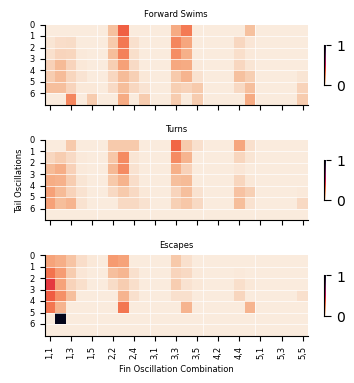

In [107]:
fig, axes= plt.subplots(3,1, figsize=(10*cm, 10*cm), facecolor='None', sharex=True, sharey=True)
axes= axes.ravel()

for iind in range(3):
    # Plotting the heatmap
    sns.heatmap(norm_hists[iind], cmap='rocket_r', ax=axes[iind], cbar_kws={'shrink':0.5}, vmin=0, vmax=1)
    axes[iind].set_yticks(bins_tails)
    axes[iind].set_yticklabels(bins_tails, rotation=0, fontsize=f_size)
    axes[iind].set_ylabel(' ')
    
    for i in tail_borders:
        axes[iind].axhline(i, c='w', lw=lw)
    for i in borders:
        axes[iind].axvline(i, c='w', lw=lw)
    
axes[1].set_ylabel('Tail Oscillations', fontsize=f_size)
axes[-1].set_xlabel('Fin Oscillation Combination', fontsize=f_size)
axes[0].set_title('Forward Swims', fontsize=f_size)
axes[1].set_title('Turns', fontsize=f_size)
axes[2].set_title('Escapes', fontsize=f_size)

for ax in axes:
    ax.set_yticks(np.arange(0,7,1))
    ax.set_yticklabels(np.arange(0,7,1), fontsize=f_size)
    ax.tick_params(axis='both', which='major', labelsize=f_size)
# fig.suptitle('Norm. oscillation combinaton counts', fontsize=f_size)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.tight_layout()

fig.savefig(save_figure_path /'oscillation_combi_split_.pdf', dpi=300)
fig.savefig(save_figure_path /'oscillation_combi_split_.png', dpi=300)